# Z3-Python-08 : Ordonnancement de taches (Job-Shop Scheduling)



[← Serie Z3-Python](README.md) | [Z3-Python-07 (style declaratif LINQ) →](Z3-Python-07-Style-Declaratif-Linq.ipynb)



## Le probleme



Le **job-shop scheduling** est un probleme canonique d'optimisation combinatoire : on dispose de $m$ machines et de $n$ jobs, chaque job etant une **sequence d'operations** (une par machine) de durees donnees. On veut trouver un ordonnancement (date de debut de chaque operation) qui :



1. **respecte l'ordre** des operations de chaque job (precedence),

2. **n'utilise chaque machine qu'une fois a la fois** (exclusion disjonctive),

3. **minimise le makespan** $C_{\max}$ (la date de fin de la derniere operation).



Ce probleme est **NP-difficile** : il n'existe pas d'algorithme polynomial connu, et une approche gloutonne (heuristique) rate souvent l'optimum. C'est typiquement la ou un solveur SMT comme Z3 **brille** : on decrit les contraintes (precedence + exclusion) et l'objectif (minimiser $C_{\max}$), et `Optimize` trouve l'ordonnancement optimal.



**Ce notebook montre** : (a) une heuristique gloutonne FIFO sous-optimale, (b) la modelisation Z3 avec la contrainte disjonctive `Or(... , ...)`, (c) l'optimum trouve par `Optimize.minimize`, et (d) un diagramme de Gantt comparant les deux. Il porte en Python l'exemple C# [11_Job_Shop_Scheduling](../Z3/11_Job_Shop_Scheduling.ipynb) de la serie sœur Z3.Linq.

In [1]:
# Imports : z3 (solveur SMT) + matplotlib (diagramme de Gantt).

import os

import z3

import matplotlib

import matplotlib.pyplot as plt



# En mode batch (Papermill/nbconvert headless), on desactive le mode interactif.

# On garde le backend inline par defaut (capture les figures au plt.show()).

BATCH_MODE = os.getenv("BATCH_MODE", "false").lower() in ("true", "1", "yes")

if BATCH_MODE:

    plt.ioff()



print("z3 version :", z3.get_version_string())

z3 version : 4.15.4


## Instance de reference : 3 jobs x 2 machines



On encode l'instance comme un dictionnaire : chaque job est la liste ordonnee de ses operations, chaque operation etant un couple `(machine, duree)`.



| Job | Operation 1 | Operation 2 |

|-----|-------------|-------------|

| J0  | M0 (3h)     | M1 (3h)     |

| J1  | M1 (2h)     | M0 (2h)     |

| J2  | M0 (2h)     | M1 (2h)     |



Notez que J0 et J2 commencent par M0, mais J1 commence par M1 : les jobs n'ont pas tous le meme parcours.

In [2]:
# Instance : 3 jobs x 2 machines (M0, M1).

# Format : jobs[j] = [(machine, duree), (machine, duree)] dans l'ordre des operations.

MACHINES = ["M0", "M1"]

jobs = {

    "J0": [("M0", 3), ("M1", 3)],  # 3h sur M0 puis 3h sur M1

    "J1": [("M1", 2), ("M0", 2)],  # 2h sur M1 puis 2h sur M0

    "J2": [("M0", 2), ("M1", 2)],  # 2h sur M0 puis 2h sur M1

}

JOB_NAMES = list(jobs.keys())



print(f"Instance : {len(JOB_NAMES)} jobs x {len(MACHINES)} machines")

for j in JOB_NAMES:

    parcours = " puis ".join(f"{m}({d}h)" for m, d in jobs[j])

    print(f"  {j} : {parcours}")

Instance : 3 jobs x 2 machines
  J0 : M0(3h) puis M1(3h)
  J1 : M1(2h) puis M0(2h)
  J2 : M0(2h) puis M1(2h)


## Approche gloutonne : ordonnancement FIFO



Avant Z3, essayons une **heuristique simple** : on schedule les jobs dans l'ordre (J0, puis J1, puis J2), et pour chaque job on place chaque operation **le plus tot possible** (des que la machine est libre et que l'operation precedente du job est terminee).



Cette strategie FIFO est rapide mais **myope** : elle ne regarde pas plus loin que le job courant, et peut laisser une machine inutilisee la ou un autre ordre aurait mieux equilibre la charge.

In [3]:
def greedy_fifo(jobs, machine_names):

    """Ordonnancement glouton : schedule chaque job dans l'ordre, chaque operation ASAP."""

    machine_free = {m: 0 for m in machine_names}  # disponibilite de chaque machine

    schedule = {}

    for j in jobs:

        schedule[j] = []

        for (m, d) in jobs[j]:

            job_ready = schedule[j][-1][1] + schedule[j][-1][2] if schedule[j] else 0

            start = max(machine_free[m], job_ready)

            schedule[j].append((m, start, d))

            machine_free[m] = start + d

    cmax = max(s[1] + s[2] for j in schedule for s in schedule[j])

    return schedule, cmax



greedy_schedule, greedy_cmax = greedy_fifo(jobs, MACHINES)

print(f"Glouton FIFO : Cmax = {greedy_cmax}h")

for j in JOB_NAMES:

    ops = ", ".join(f"{m}[{s},{s+d}]" for m, s, d in greedy_schedule[j])

    print(f"  {j} : {ops}")

Glouton FIFO : Cmax = 14h
  J0 : M0[0,3], M1[3,6]
  J1 : M1[6,8], M0[8,10]
  J2 : M0[10,12], M1[12,14]


## Modelisation Z3 : variables et contraintes



Le passage au declaratif. On introduit une variable entiere $s_{j,k}$ = date de debut de l'operation $k$ du job $j$, plus une variable $C_{\max}$ pour le makespan. Les contraintes se traduisent directement :



1. **Precedence intra-job** : l'operation $k$ commence apres la fin de l'operation $k{-}1$ :  $s_{j,k} \ge s_{j,k-1} + d_{j,k-1}$.

2. **Exclusion disjonctive** (le coeur du modele) : pour deux operations $a$ et $b$ sur la **meme** machine, l'une doit finir avant que l'autre commence :  $s_a + d_a \le s_b$ **OU** $s_b + d_b \le s_a$. C'est cette disjonction `Or(...)` (non-lineaire, difficile pour un simple parcours) qui fait toute la valeur du solveur.

3. **Objectif** : minimiser $C_{\max} = \max_{j,k}(s_{j,k} + d_{j,k})$, via `Optimize.minimize`.



La borne superieure sure $C_{\max} \le$ somme de toutes les durees (cas ou tout serait sequentialise) garantit un domaine fini au solveur.

In [4]:
def solve_jobshop(jobs, machine_names):

    """Modelise le job-shop en Z3 et minimise le makespan (Cmax)."""

    opt = z3.Optimize()

    job_names = list(jobs.keys())

    horizon = sum(d for j in jobs for (_, d) in jobs[j])  # borne sup sure



    # Variables de debut : start[j][k]

    start = {j: [z3.Int(f"s_{j}_{k}") for k in range(len(jobs[j]))] for j in job_names}

    cmax = z3.Int("cmax")



    # (1) Domaine + precedence intra-job + borne makespan

    for j in job_names:

        for k, (m, d) in enumerate(jobs[j]):

            opt.add(start[j][k] >= 0)

            opt.add(start[j][k] + d <= cmax)

            if k > 0:

                _, pd = jobs[j][k - 1]

                opt.add(start[j][k] >= start[j][k - 1] + pd)



    # (2) Exclusion disjonctive : deux operations sur la MEME machine ne se chevauchent pas

    for m in machine_names:

        ops_on_m = [(j, k, jobs[j][k][1])

                    for j in job_names for k in range(len(jobs[j]))

                    if jobs[j][k][0] == m]

        for a in range(len(ops_on_m)):

            for b in range(a + 1, len(ops_on_m)):

                ja, ka, da = ops_on_m[a]

                jb, kb, db = ops_on_m[b]

                opt.add(z3.Or(start[ja][ka] + da <= start[jb][kb],

                             start[jb][kb] + db <= start[ja][ka]))



    # (3) Objectif : minimiser le makespan

    opt.add(cmax <= horizon)

    opt.minimize(cmax)

    assert opt.check() == z3.sat, "Instance insatisfiable"

    model = opt.model()

    schedule = {j: [(jobs[j][k][0], model[start[j][k]].as_long(), jobs[j][k][1])

                    for k in range(len(jobs[j]))] for j in job_names}

    return schedule, model[cmax].as_long()



opt_schedule, opt_cmax = solve_jobshop(jobs, MACHINES)

print(f"Z3 optimal : Cmax = {opt_cmax}h  (glouton = {greedy_cmax}h, gain = {greedy_cmax - opt_cmax}h)")

Z3 optimal : Cmax = 8h  (glouton = 14h, gain = 6h)


## Resultat optimal



Le solveur trouve l'ordonnancement de makespan **minimal**. Comparons le detail op par op : la ou le glouton sequentialisait trop, Z3 entrelace les jobs (une operation d'un job pendant le creux d'un autre) pour reduire le temps total.

In [5]:
print("Comparaison glouton vs Z3 optimal :\n")

for j in JOB_NAMES:

    g = ", ".join(f"{m}[{s},{s+d}]" for m, s, d in greedy_schedule[j])

    o = ", ".join(f"{m}[{s},{s+d}]" for m, s, d in opt_schedule[j])

    print(f"  {j}")

    print(f"    glouton : {g}")

    print(f"    optimal : {o}")

print(f"\nMakespan : glouton {greedy_cmax}h -> optimal {opt_cmax}h (gain de {greedy_cmax - opt_cmax}h, {100*(greedy_cmax-opt_cmax)/greedy_cmax:.0f}%)")

Comparaison glouton vs Z3 optimal :

  J0
    glouton : M0[0,3], M1[3,6]
    optimal : M0[0,3], M1[3,6]
  J1
    glouton : M1[6,8], M0[8,10]
    optimal : M1[1,3], M0[6,8]
  J2
    glouton : M0[10,12], M1[12,14]
    optimal : M0[4,6], M1[6,8]

Makespan : glouton 14h -> optimal 8h (gain de 6h, 43%)


## Visualisation : diagramme de Gantt



Le diagramme de Gantt rend visible la difference : chaque ligne est une machine, chaque barre coloree une operation. Le glouton (haut) laisse des trous ; l'optimal Z3 (bas) tasse les operations pour finir plus tot.

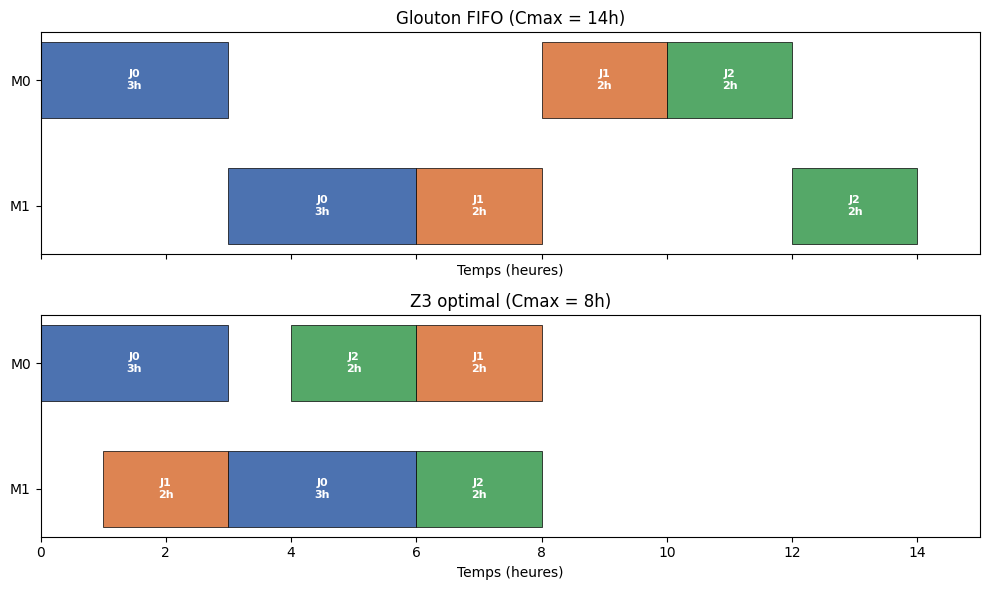

Diagramme de Gantt : glouton (haut) vs optimal (bas).


In [6]:
COLORS = {"J0": "#4C72B0", "J1": "#DD8452", "J2": "#55A868", "J3": "#C44E52"}



def draw_gantt(ax, schedule, title, machine_names, xmax):

    for mi, m in enumerate(machine_names):

        for j in schedule:

            for (mach, s, d) in schedule[j]:

                if mach == m:

                    ax.barh(mi, d, left=s, height=0.6,

                            color=COLORS.get(j, "gray"), edgecolor="black", linewidth=0.5)

                    ax.text(s + d / 2, mi, f"{j}\n{d}h", ha="center", va="center",

                            fontsize=8, color="white", fontweight="bold")

    ax.set_yticks(range(len(machine_names)))

    ax.set_yticklabels(machine_names)

    ax.set_xlabel("Temps (heures)")

    ax.set_title(title)

    ax.set_xlim(0, xmax + 1)

    ax.invert_yaxis()



xmax = max(greedy_cmax, opt_cmax)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

draw_gantt(axes[0], greedy_schedule, f"Glouton FIFO (Cmax = {greedy_cmax}h)", MACHINES, xmax)

draw_gantt(axes[1], opt_schedule, f"Z3 optimal (Cmax = {opt_cmax}h)", MACHINES, xmax)

fig.tight_layout()

plt.show()

print("Diagramme de Gantt : glouton (haut) vs optimal (bas).")

## Exercices



Les trois exercices suivants vous font manipuler le modele : etendre l'instance (1), ajouter une contrainte metier de deadline (2), et monter en dimension avec une troisieme machine (3). Chaque stub reutilise `solve_jobshop` defini plus haut.

### Exercice 1 -- Ajout d'un quatrieme job



**Objectif** : ajouter un job `J3 = [("M1", 1), ("M0", 3)]` (1h sur M1 puis 3h sur M0) et re-resoudre. Observez comment le makespan optimal augmente (ou non) et comment Z3 re-entrelace les operations.



**Indices** : copiez le dict `jobs` dans `jobs_4` avec l'entree J3 supplementaire ; appelez `solve_jobshop(jobs_4, MACHINES)`.

In [7]:
# Exercice 1 : ajoutez un quatrieme job J3 et re-resolvez.

# Etape 1 : definissez jobs_4 = dict(jobs) puis jobs_4["J3"] = [("M1", 1), ("M0", 3)].

# Etape 2 : resolvez via solve_jobshop(jobs_4, MACHINES).

# Etape 3 : comparez le nouveau Cmax a l'optimum 3-jobs (opt_cmax).



def resoudre_4_jobs():

    """Retourne (schedule, cmax) pour l'instance 3 jobs + J3."""

    # TODO etudiant : construire jobs_4 et appeler solve_jobshop

    return None



print("Exercice 1 a completer : ajouter un 4eme job et mesurer le nouveau Cmax optimal.")

Exercice 1 a completer : ajouter un 4eme job et mesurer le nouveau Cmax optimal.


### Exercice 2 -- Contrainte d'urgence (deadline)



**Objectif** : imposer que le job `J0` termine avant $t = 7$ (deadline). Ajoutez cette contrainte au modele et verifyez que le makespan optimal augmente (la deadline force un ordonnancement moins efficace).



**Indices** : la fin de J0 est `start["J0"][-1] + duree_derniere_op` ; ajoutez `opt.add(... <= 7)` avant `opt.minimize`. Modifiez `solve_jobshop` ou creez une variante.

In [8]:
# Exercice 2 : ajoutez une deadline (J0 doit terminer avant t=7).

# Indice : opt.add(start["J0"][-1] + jobs["J0"][-1][1] <= 7) avant opt.minimize.

# Etape 1 : copiez solve_jobshop en solve_jobshop_deadline(jobs, machines, deadline_j0=7).

# Etape 2 : resolvez et comparez le Cmax a opt_cmax (sans deadline).



def solve_jobshop_deadline(jobs, machine_names, deadline_j0=7):

    """Job-shop avec une deadline sur J0."""

    # TODO etudiant : modeliser + ajouter la deadline + minimiser

    return None



print("Exercice 2 a completer : mesurer le surcout d'une deadline sur J0.")

Exercice 2 a completer : mesurer le surcout d'une deadline sur J0.


### Exercice 3 -- Extension a 3 machines



**Objectif** : etendre l'instance a 3 machines (M0, M1, M2) avec des jobs a 3 operations chacun, et verifyez que `solve_jobshop` generalize sans modification de code (le modele est parametre par les donnees).



**Indices** : definissez `MACHINES_3 = ["M0", "M1", "M2"]` et des `jobs_3` ou chaque job a 3 operations sur des machines distinctes ; la fonction `solve_jobshop` gere deja le cas general.

In [9]:
# Exercice 3 : etendez l'instance a 3 machines, 3 operations par job.

# Indice : MACHINES_3 = ["M0", "M1", "M2"], jobs_3 = {j: [(m1,d1),(m2,d2),(m3,d3)], ...}.

# Etape 1 : definissez jobs_3 (3 jobs, chacun 3 operations sur des machines distinctes).

# Etape 2 : resolvez via solve_jobshop(jobs_3, MACHINES_3).

# Question : le temps de resolution grimpe-t-il avec 3 machines ? Mesurez-le.



def resoudre_3_machines():

    """Retourne (schedule, cmax) pour une instance 3 machines."""

    # TODO etudiant : definir jobs_3 + MACHINES_3 et appeler solve_jobshop

    return None



print("Exercice 3 a completer : generaliser a 3 machines et observer le temps de resolution.")

Exercice 3 a completer : generaliser a 3 machines et observer le temps de resolution.


## Conclusion



Le job-shop scheduling illustre le gain du **declaratif** sur une classe de problemes ou l'heuristique gloutonne est structurellement sous-optimale :



- La **contrainte disjonctive** `Or(s_a + d_a <= s_b, s_b + d_b <= s_a)` (exclusion mutuelle sur une machine) est difficile a coder en imperatif sans enumerer tous les ordres possibles ; Z3 la traite nativement.

- `Optimize.minimize` trouve le makespan **optimal** (prouvablement minimal), la ou FIFO se contente d'un ordonnancement realisable mais myope.

- Le modele est **parametre par les donnees** : ajouter un job, une machine ou une deadline se fait en modifiant l'instance ou en ajoutant une contrainte, sans re-ecrire l'algorithme de resolution.



**Limites** : sur de tres grandes instances (dizaines de jobs x dizaines de machines), le solveur peut devenir lent — c'est le prix de l'optimalite garantie. Dans ce cas, on combine souvent Z3 avec des heuristiques (fournir un ordonnancement glouton comme borne superieure aide le solveur a pruner).



Suite logique : retour a la [serie Z3-Python](README.md), ou explorez la version C# [Z3.Linq](../Z3/README.md) qui aborde le meme probleme via une couche declarative LINQ.